# Investigating Mouse Pancreas Atlas

## Load dataset

In [5]:
import scanpy as sc
import anndata as ad

adata = ad.read_zarr('data/Hrovatin2023_preprocessed.zarr')
adata

AnnData object with n_obs × n_vars = 301796 × 31202
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO

## Subset beta cells

Check which cell types exist in the dataset

In [6]:
adata.obs['cell_type_reannotatedIntegrated'].value_counts()


cell_type_reannotatedIntegrated
beta             102143
alpha             40935
immune            31703
E non-endo.       29177
delta             24775
stellate a.       18332
endothelial       13469
ductal             8742
E endo.            7748
gamma              6999
beta+delta         5104
stellate q.        4970
alpha+delta        1901
beta+gamma         1209
delta+gamma        1069
endo. prolif.       887
lowQ                853
alpha+beta          683
schwann             617
acinar              480
Name: count, dtype: int64

In [7]:
beta_subset = adata[
    adata.obs['cell_type_reannotatedIntegrated'] == 'beta'
].copy()

## Recompute kNN

In [16]:
sc.pp.neighbors(beta_subset, n_neighbors=15, use_rep='X_integrated_umap_beta')

In [17]:
beta_subset.obs.columns

Index(['batch_integration', 'dataset', 'design', 'cell_cycle_phase',
       'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering',
       'strain', 'age', 'cell_type_originalDataset_unified',
       'cell_type_originalDataset', 'cell_type_reannotatedIntegrated',
       'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts',
       'age_approxDays', 'dataset__design__sample',
       'cell_subtype_immune_reannotatedIntegrated',
       'cell_subtype_endothelial_reannotatedIntegrated',
       'emptyDrops_LogProb_scaled',
       'cell_subtype_beta_coarse_reannotatedIntegrated',
       'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3',
       'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11',
       'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19',
       'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_

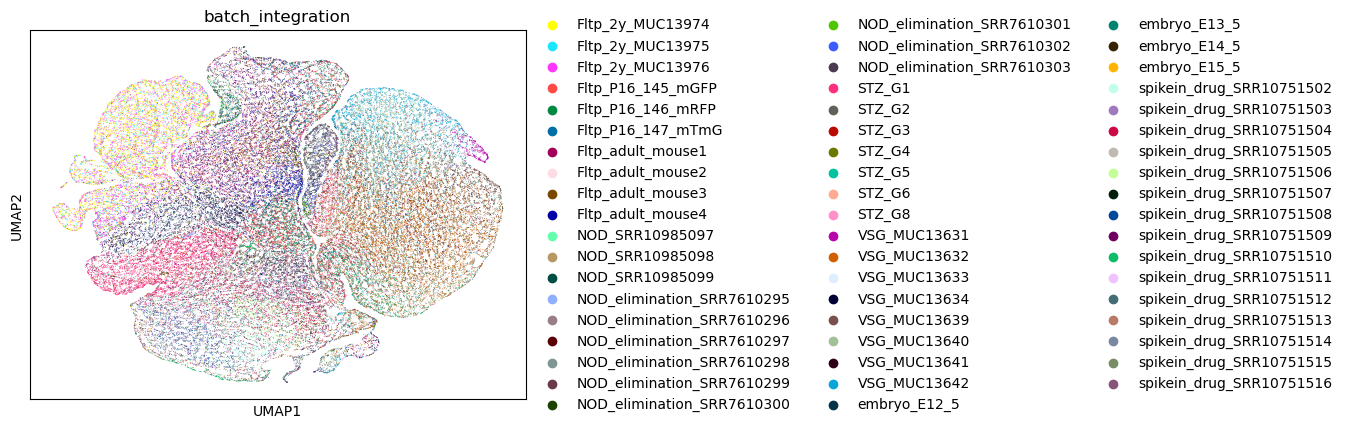

In [18]:
sc.tl.umap(beta_subset)
sc.pl.umap(beta_subset, color='batch_integration')

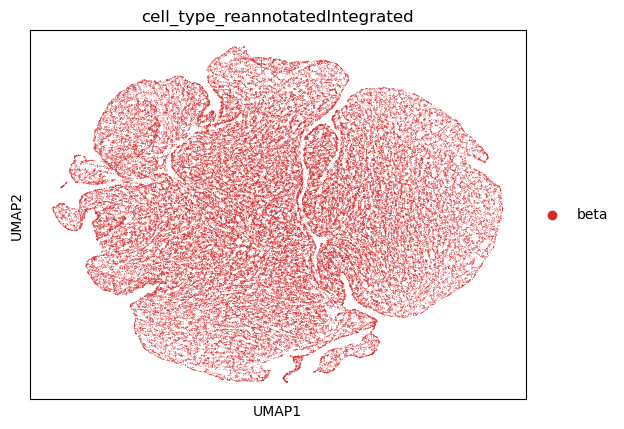

In [19]:
sc.pl.umap(beta_subset, color='cell_type_reannotatedIntegrated')

You can see the successful batch integration here

### plot substates

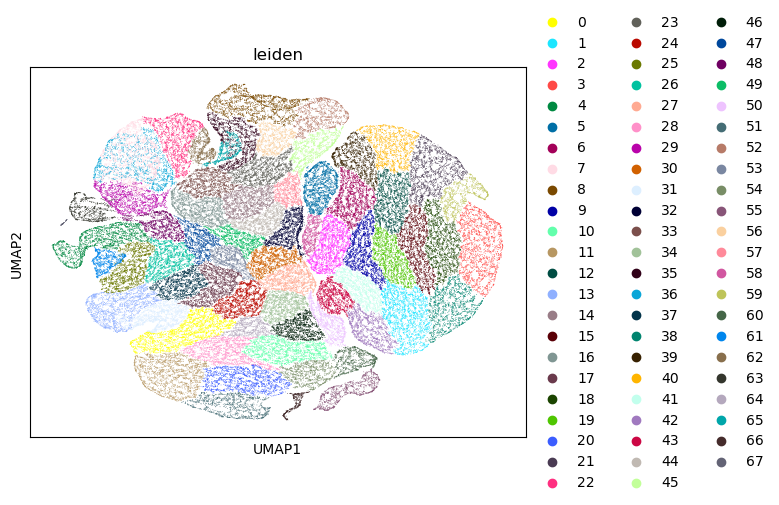

In [20]:
sc.tl.leiden(beta_subset, resolution=0.5)
sc.pl.umap(beta_subset, color='leiden')

Cells with similar transcriptomes cluster together

## plot marker genes

In [21]:
marker_genes = ['Ppy', 'Ins2', 'Scg2', 'Iapp', 'Cltrn', 'Pcsk2', 'Chga']

In [14]:
print(beta_subset.var.columns)

Index(['present_Fltp_2y', 'present_Fltp_adult', 'present_Fltp_P16',
       'present_NOD', 'present_NOD_elimination', 'present_spikein_drug',
       'present_embryo', 'present_VSG', 'present_STZ', 'feature_is_filtered',
       'feature_name', 'feature_reference', 'feature_biotype',
       'feature_length', 'feature_type', 'highly_variable', 'means',
       'dispersions', 'dispersions_norm', 'highly_variable_nbatches',
       'highly_variable_intersection'],
      dtype='object')


In [15]:
beta_subset.var[['feature_name']].head(10)

,feature_name
ENSMUSG00000000001,Gnai3_ENSMUSG00000000001
ENSMUSG00000000003,Pbsn_ENSMUSG00000000003
ENSMUSG00000000028,Cdc45_ENSMUSG00000000028
ENSMUSG00000000031,H19_ENSMUSG00000000031
ENSMUSG00000000037,Scml2_ENSMUSG00000000037
ENSMUSG00000000049,Apoh_ENSMUSG00000000049
ENSMUSG00000000056,Narf_ENSMUSG00000000056
ENSMUSG00000000058,Cav2_ENSMUSG00000000058
ENSMUSG00000000078,Klf6_ENSMUSG00000000078
ENSMUSG00000000085,Scmh1


I can see that the feature name is gene symbol _ some ID, so I try to map the gene symbol to the ID

In [10]:
marker_genes = ['Ppy', 'Ins2', 'Scg2', 'Iapp', 'Cltrn', 'Pcsk2', 'Chga']

symbol_to_ID = {
    row['feature_name'].split('_')[0]: idx
    for idx, row in gamma_subset.var.iterrows()
}

valid_genes = [symbol_to_ID[gene] for gene in marker_genes if gene in symbol_to_ID]

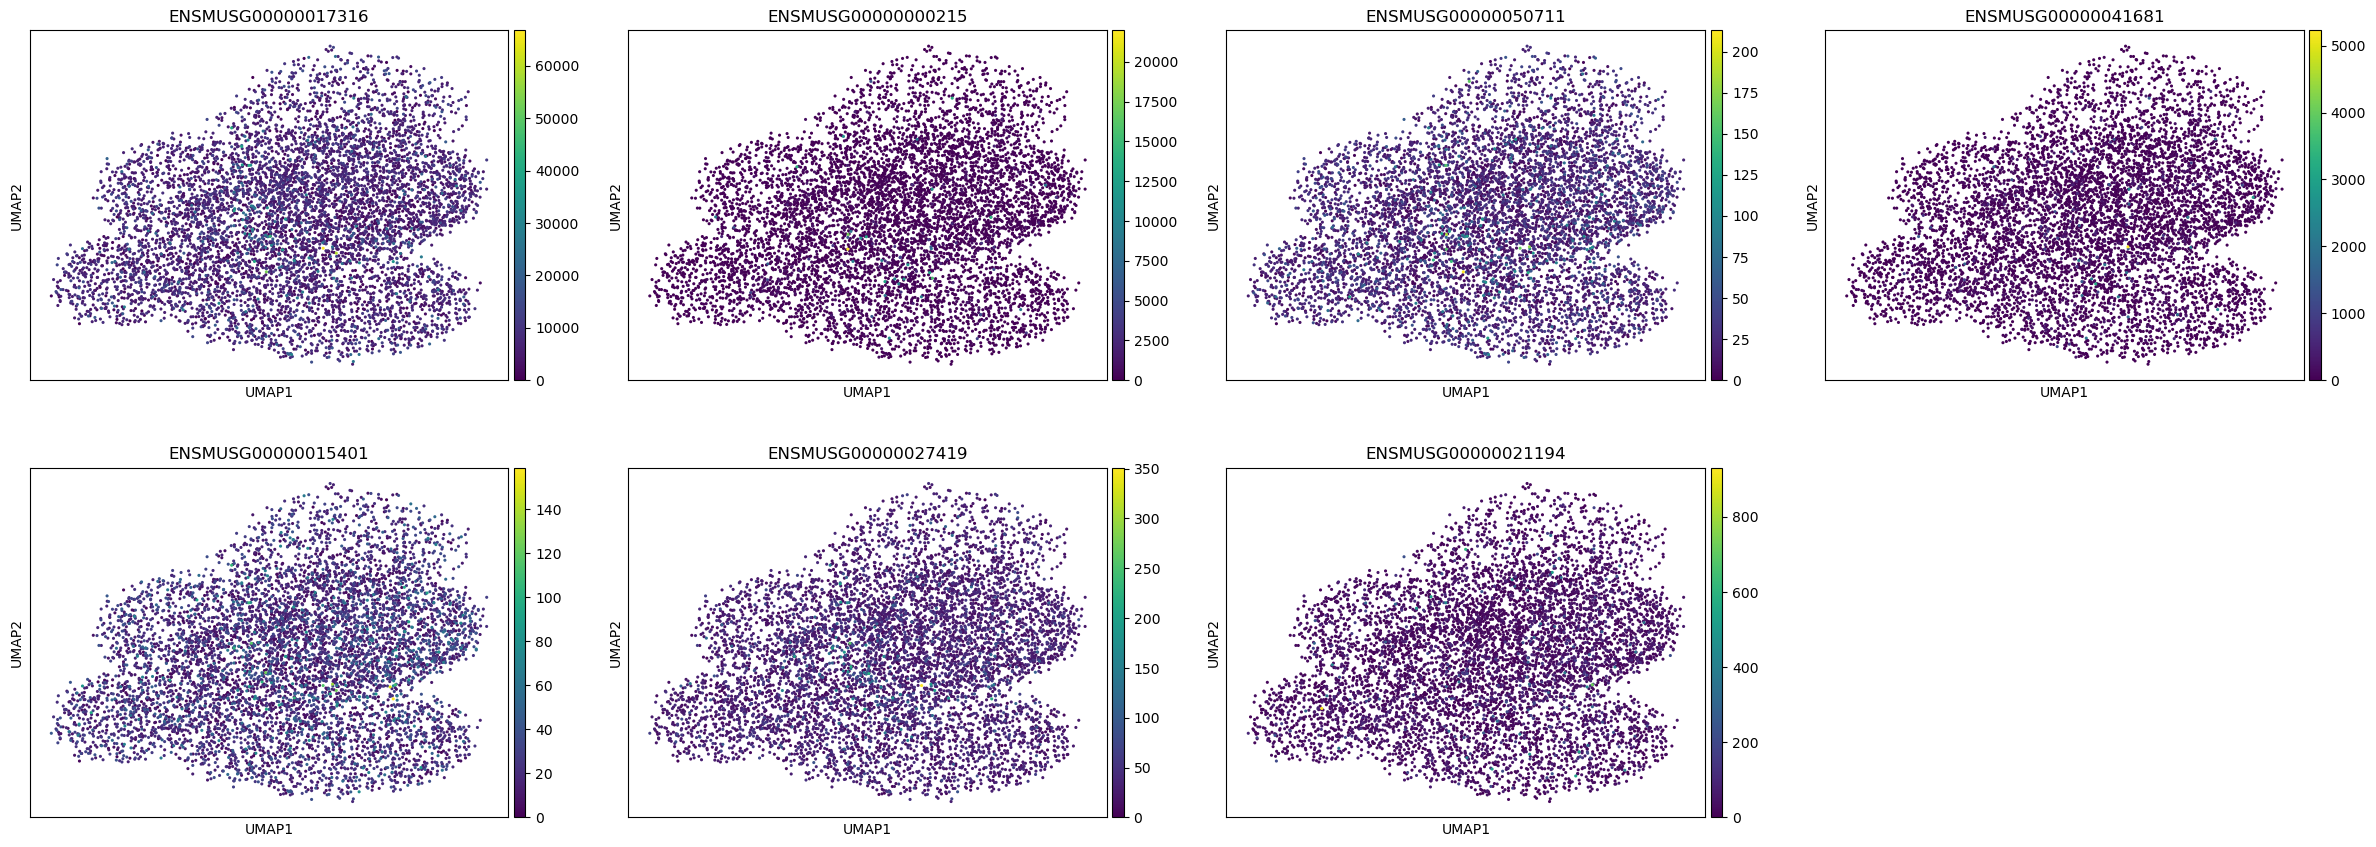

In [ ]:
sc.pl.umap(beta_subset, color=valid_genes, cmap='viridis', size=20)

### against cell type

In [ ]:
print(beta_subset.obs.columns)

Index(['batch_integration', 'dataset', 'design', 'cell_cycle_phase',
       'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering',
       'strain', 'age', 'cell_type_originalDataset_unified',
       'cell_type_originalDataset', 'cell_type_reannotatedIntegrated',
       'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts',
       'age_approxDays', 'dataset__design__sample',
       'cell_subtype_immune_reannotatedIntegrated',
       'cell_subtype_endothelial_reannotatedIntegrated',
       'emptyDrops_LogProb_scaled',
       'cell_subtype_beta_coarse_reannotatedIntegrated',
       'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3',
       'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11',
       'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19',
       'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_

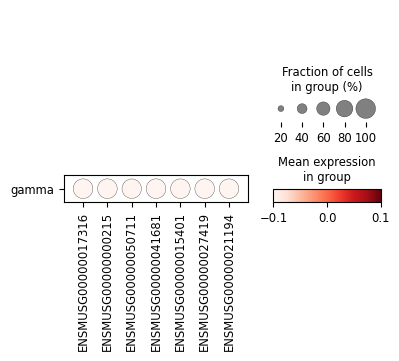

In [ ]:
sc.pl.dotplot(beta_subset, valid_genes, groupby='cell_type_reannotatedIntegrated', standard_scale='var')

It doesn't really mean anything..